In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow import keras

In [14]:
data = pd.read_csv('https://raw.githubusercontent.com/amankharwal/Website-data/master/auto-mpg.csv')
excel_file = 'auto-mpg.xlsx'
data.to_excel(excel_file, index=False)
print(f"DataFrame has been saved to {excel_file}")
data.sample(5)

DataFrame has been saved to auto-mpg.xlsx


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
217,30.0,4,111.0,80,2155,14.8,77,1,buick opel isuzu deluxe
385,38.0,4,91.0,67,1995,16.2,82,3,datsun 310 gx
181,33.0,4,91.0,53,1795,17.5,75,3,honda civic cvcc
250,19.4,8,318.0,140,3735,13.2,78,1,dodge diplomat
187,17.5,8,305.0,140,4215,13.0,76,1,chevrolet chevelle malibu classic


In [15]:
data['USA'] = (data['origin'] == 1)*1.0
data['europe'] = (data['origin'] == 2)*1.0
data['japan'] = (data['origin'] == 3)*1.0
data['horsepower'] = pd.to_numeric(data['horsepower'], errors='coerce')
data['horsepower'] = data['horsepower'].fillna(data['horsepower'].mean())

In [16]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data['car name'] = le.fit_transform(data['car name'])
x = data.drop(columns=['mpg', 'origin'])
y = data['mpg']

In [17]:
X_train, X_test, Y_train, Y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print("X_train shape:", X_train.shape)
print("Y_train range:", Y_train.min(), "to", Y_train.max())
x.head()
y.head()

X_train shape: (318, 10)
Y_train range: 9.0 to 46.6


,mpg
0,18.0
1,15.0
2,18.0
3,16.0
4,17.0


In [18]:
model = Sequential([
    Dense(64, input_dim=X_train.shape[1], activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
class PrintDot(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs):
        if epoch % 100 == 0:
            print('')
        print('.', end='')
EPOCHS = 1000
scaler = StandardScaler()
normed_train_data = scaler.fit_transform(X_train)
normed_test_data = scaler.transform(X_test)
train_labels = Y_train
test_labels = Y_test
history = model.fit(
    normed_train_data, train_labels,
    epochs=EPOCHS, validation_split=0.2, verbose=0,
    callbacks=[PrintDot()]
)


....................................................................................................
....................................................................................................
....................................................................................................
....................................................................................................
....................................................................................................
....................................................................................................
....................................................................................................
....................................................................................................
....................................................................................................
..........................................................................................

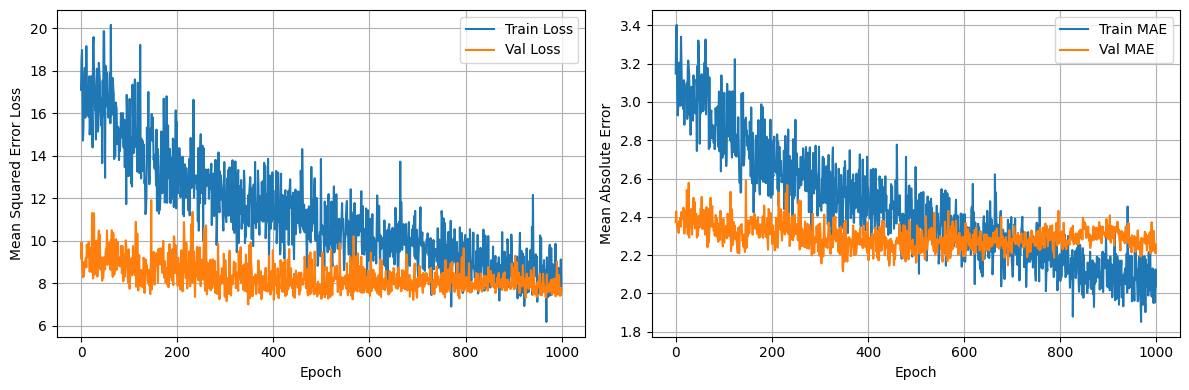

In [21]:
def plot_history(history):
    hist = pd.DataFrame(history.history)
    hist['epoch'] = history.epoch
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.xlabel('Epoch')
    plt.ylabel('Mean Squared Error Loss')
    plt.plot(hist['epoch'], hist['loss'], label='Train Loss')
    plt.plot(hist['epoch'], hist['val_loss'], label='Val Loss')
    plt.legend()
    plt.grid(True)
    plt.subplot(1, 2, 2)
    plt.xlabel('Epoch')
    plt.ylabel('Mean Absolute Error')
    plt.plot(hist['epoch'], hist['mae'], label='Train MAE')
    plt.plot(hist['epoch'], hist['val_mae'], label='Val MAE')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
plot_history(history)

In [22]:
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=50)
model = Sequential([
    Dense(64, input_dim=X_train.shape[1], activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)
history = model.fit(
    normed_train_data, train_labels,
    epochs=EPOCHS,
    validation_split=0.2,
    verbose=0,
    callbacks=[early_stop, PrintDot()]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



....................................................................................................
....................................................................................................
............................................

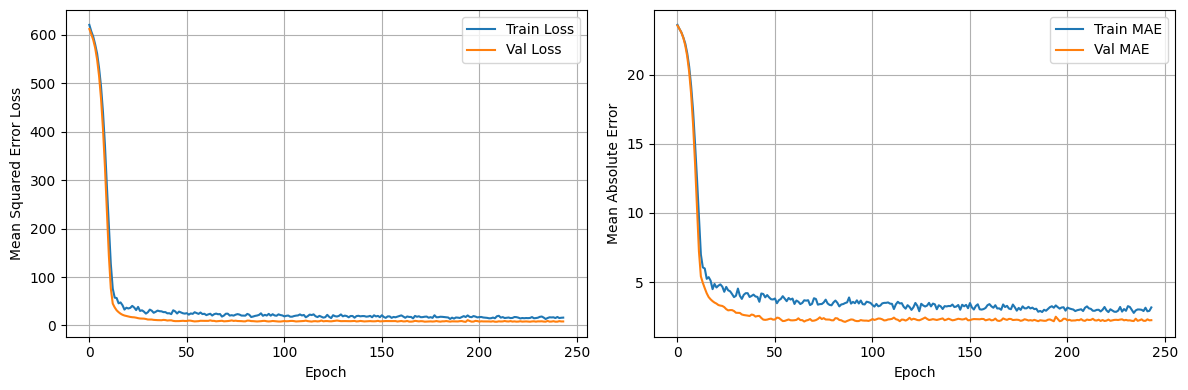


Testing set MSE Loss:  5.37
Testing set MAE:  1.76 MPG
Testing set RMSE:  2.32 MPG


In [23]:
print("\n")
plot_history(history)
test_loss, test_mae = model.evaluate(normed_test_data, test_labels, verbose=0)
print("\n" + "="*50)
print("Testing set MSE Loss: {:5.2f}".format(test_loss))
print("Testing set MAE: {:5.2f} MPG".format(test_mae))
print("Testing set RMSE: {:5.2f} MPG".format(np.sqrt(test_loss)))
print("="*50)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step


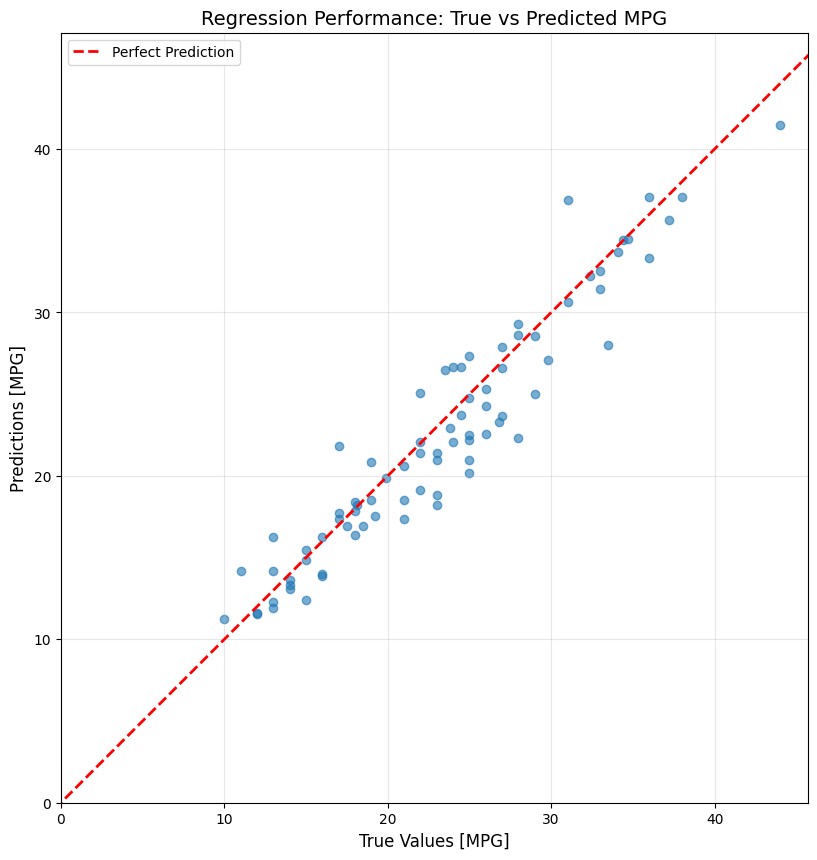

In [24]:
test_predictions = model.predict(normed_test_data).flatten()
plt.figure(figsize=(10, 10))
plt.scatter(test_labels, test_predictions, alpha=0.6)
plt.xlabel('True Values [MPG]', fontsize=12)
plt.ylabel('Predictions [MPG]', fontsize=12)
plt.title('Regression Performance: True vs Predicted MPG', fontsize=14)
plt.axis('equal')
plt.axis('square')
plt.xlim([0, plt.xlim()[1]])
plt.ylim([0, plt.ylim()[1]])
plt.plot([-100, 100], [-100, 100], 'r--', linewidth=2, label='Perfect Prediction')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


R² Score: 0.9001


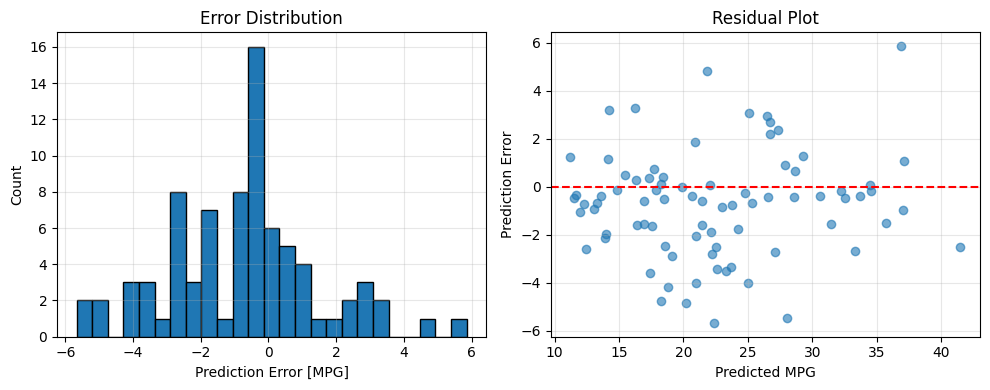

In [25]:
from sklearn.metrics import r2_score
r2 = r2_score(test_labels, test_predictions)
print(f"\nR² Score: {r2:.4f}")
error = test_predictions - test_labels
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(error, bins=25, edgecolor='black')
plt.xlabel('Prediction Error [MPG]')
plt.ylabel('Count')
plt.title('Error Distribution')
plt.grid(True, alpha=0.3)
plt.subplot(1, 2, 2)
plt.scatter(test_predictions, error, alpha=0.6)
plt.xlabel('Predicted MPG')
plt.ylabel('Prediction Error')
plt.title('Residual Plot')
plt.axhline(y=0, color='r', linestyle='--')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()